In [9]:
import matplotlib.pyplot as plt
import numpy as np
from imp import reload
import scipy.spatial as sc
radTodDeg = 180/np.pi 

def round(x, base=1):
    return base * np.round(x/base)

def roundInt(x):
    return np.round(x).astype(np.int)

%load_ext line_profiler


The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [3]:
size = 8
if size%2 == 1:
    size += 1
size2 = np.int(size/2)
if size2%2 == 0:
    size2 += 1
size = [size,size2]

In [4]:
dPhi = 2*np.pi/(size[0])
dTheta = np.pi/(size[1]-1)

phi = np.linspace(-np.pi,np.pi-dPhi,size[0])
theta = np.linspace(-np.pi/2,np.pi/2,size[1])


phi2d = np.array([phi,]*size[1])
theta2d = np.array([theta,]*size[0]).transpose()

dThetaIm =  np.array([[np.pi/size[1],]*size[0],]*size[1])
dPhiIm = np.cos(theta2d)*np.array([[2*np.pi/size[0],]*size[0],]*size[1])



dThetadPhiIm = dThetaIm*dPhiIm

sinThetaIm = np.sin(theta2d) * dThetadPhiIm
cosThetaCosPhiIm = np.cos(theta2d) * np.cos(phi2d) * dThetadPhiIm 
cosThetaSinPhiIm = np.cos(theta2d) * np.sin(phi2d) * dThetadPhiIm


dTheta = np.matrix.flatten(dThetaIm)
dPhi = np.matrix.flatten(dPhiIm)

sinTheta = np.matrix.flatten(sinThetaIm)
cosThetaCosPhi = np.matrix.flatten(cosThetaCosPhiIm)
cosThetaSinPhi = np.matrix.flatten(cosThetaSinPhiIm)


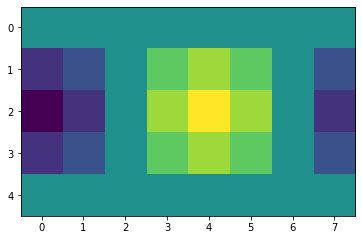

In [40]:
plt.imshow(np.cos(theta2d) * np.cos(phi2d))

In [36]:
phi2d

array([[-3.14159265, -2.35619449, -1.57079633, -0.78539816,  0.        ,
         0.78539816,  1.57079633,  2.35619449],
       [-3.14159265, -2.35619449, -1.57079633, -0.78539816,  0.        ,
         0.78539816,  1.57079633,  2.35619449],
       [-3.14159265, -2.35619449, -1.57079633, -0.78539816,  0.        ,
         0.78539816,  1.57079633,  2.35619449],
       [-3.14159265, -2.35619449, -1.57079633, -0.78539816,  0.        ,
         0.78539816,  1.57079633,  2.35619449],
       [-3.14159265, -2.35619449, -1.57079633, -0.78539816,  0.        ,
         0.78539816,  1.57079633,  2.35619449]])

In [16]:
def drawSphere(Xs,R,size):
    print("start")
    dPhi = 2*np.pi/(size[0])
    dTheta = np.pi/(size[1]-1)
    theta0 = Xs[2]
    phi0 = Xs[1]

    #i don't know what approximation to use
    #thetaApp = np.arcsin(R/Xs[0])
    thetaApp = np.arctan2(R,Xs[0])
    thetaMin = round(theta0-thetaApp,dTheta)
    thetaMax = round(theta0+thetaApp,dTheta)
    thetaN = 1+roundInt((thetaMax-thetaMin)/dTheta)

    if thetaN == 1:
        thetaIdx = np.floor(size[1]/2) + np.round(((theta0/dTheta)))

        phiIdx = (np.floor(size[0]/2) + round(phi0 / dPhi))%size[0]
        vIdx = np.array([phiIdx,thetaIdx])
    else:
        theta = np.linspace(thetaMin,thetaMax,thetaN)

        thetaSpace = theta - round(theta0,dTheta)

        theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
        theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]

        thetaIdx = np.floor(size[1]/2) + np.round(((theta/dTheta)))

        ## no idea where this 2 or the 4 is coming from
        phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))

        thetaIdx = thetaIdx[~np.isnan(phiLim)]

        phiLim = phiLim[~np.isnan(phiLim)]
        phiMax =  (np.floor(size[0]/2) + round((phi0 + phiLim) / dPhi))
        phiMin =  (np.floor(size[0]/2) + round((phi0 - phiLim) / dPhi))

        idx = []

        for thetaIdx,phiIdxMin,phiIdxMax in zip(thetaIdx,phiMin,phiMax):

            if phiIdxMax-phiIdxMin >size[0] or phiIdxMax == -2147483648:
                phiIdx = np.arange(0,size[0])%size[0]


            else:
                phiIdx = np.arange(phiIdxMin,phiIdxMax+1)%size[0]
            xx = thetaIdx*np.ones(len(phiIdx))
            xx 2 = np.vstack([phiIdx,xx])
            idxLine = xx2.T
            idx.append(idxLine)
        vIdx = np.concatenate(idx)
    return roundInt(vIdx)

<ipython-input-61-8b7f1fa13802>:31: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


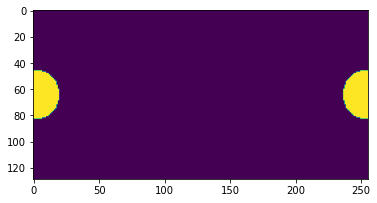

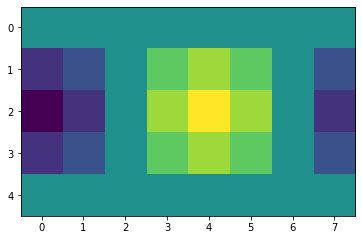

In [62]:
V = np.zeros([size[1],size[0]])
Xs  = [2,-np.pi,0]
vIdx = drawSphere(Xs,1,size)
try:
    V[vIdx[:,1],vIdx[:,0]] = 1
except:
    V[vIdx[1],vIdx[0]] = 1
plt.imshow(V)
plt.figure()
plt.imshow(np.cos(theta2d) * np.cos(phi2d))

In [74]:
vIdx

array([8, 2])

In [20]:
def drawSphere(Xs,R,size):
    print("start")
    dPhi = 2*np.pi/(size[0])
    dTheta = np.pi/(size[1]-1)
    theta0 = Xs[2]
    phi0 = Xs[1]

    #i don't know what approximation to use
    #thetaApp = np.arcsin(R/Xs[0])
    thetaApp = np.arctan2(R,Xs[0])
    thetaMin = round(theta0-thetaApp,dTheta)
    thetaMax = round(theta0+thetaApp,dTheta)
    thetaN = 1+roundInt((thetaMax-thetaMin)/dTheta)

    if thetaN == 1:
        thetaIdx = np.floor(size[1]/2) + np.round(((theta0/dTheta)))

        phiIdx = (np.floor(size[0]/2) + round(phi0 / dPhi))%size[0]
        vIdx = np.array([phiIdx,thetaIdx])
    else:
        theta = np.linspace(thetaMin,thetaMax,thetaN)

        thetaSpace = theta - round(theta0,dTheta)

        theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
        theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]

        thetaIdx = np.floor(size[1]/2) + np.round(((theta/dTheta)))

        ## no idea where this 2 or the 4 is coming from
        phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))

        thetaIdx = thetaIdx[~np.isnan(phiLim)]

        phiLim = phiLim[~np.isnan(phiLim)]
        phiMax =  (np.floor(size[0]/2) + round((phi0 + phiLim) / dPhi))
        phiMin =  (np.floor(size[0]/2) + round((phi0 - phiLim) / dPhi))

        idx = []

        for thetaIdx,phiIdxMin,phiIdxMax in zip(thetaIdx,phiMin,phiMax):

            if phiIdxMax-phiIdxMin >size[0] or phiIdxMax == -2147483648:
                phiIdx = np.arange(0,size[0])%size[0]


            else:
                phiIdx = np.arange(phiIdxMin,phiIdxMax+1)%size[0]
            xx = thetaIdx*np.ones(len(phiIdx))
            xx = np.full(shape=len(phiIdx),fill_value=thetaIdx) 
            xx2 = np.vstack([phiIdx,xx])
            idxLine = xx2.T
            idx.append(idxLine)
        vIdx = np.concatenate(idx)
    return roundInt(vIdx)

In [21]:
V = np.zeros([size[1],size[0]])
Xs  = [2,-np.pi,0]
phiIdx,thetaIdx = drawSphere2(Xs,1,size)

start


<ipython-input-7-d9be83a48cbe>:31: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


In [11]:
thetaIdx

2.0

In [12]:
[phiIdx,thetaIdx*np.ones(len(phiIdx))]

[array([7., 0., 1.]), array([2., 2., 2.])]

In [63]:
def drawSphere(Xs,R,size):

    dPhi = 2*np.pi/(size[0])
    dTheta = np.pi/(size[1]-1)
    theta0 = Xs[2]
    phi0 = Xs[1]

    #i don't know what approximation to use
    #thetaApp = np.arcsin(R/Xs[0])
    thetaApp = np.arctan2(R,Xs[0])
    thetaMin = round(theta0-thetaApp,dTheta)
    thetaMax = round(theta0+thetaApp,dTheta)
    thetaN = 1+roundInt((thetaMax-thetaMin)/dTheta)

    if thetaN == 1:
        thetaIdx = np.floor(size[1]/2) + np.round(((theta0/dTheta)))

        phiIdx = (np.floor(size[0]/2) + round(phi0 / dPhi))%size[0]
        vIdx = np.array([phiIdx,thetaIdx])
    else:
        theta = np.linspace(thetaMin,thetaMax,thetaN)

        thetaSpace = theta - round(theta0,dTheta)

        theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
        theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]

        thetaIdx = np.floor(size[1]/2) + np.round(((theta/dTheta)))

        ## no idea where this 2 or the 4 is coming from
        phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))

        thetaIdx = thetaIdx[~np.isnan(phiLim)]

        phiLim = phiLim[~np.isnan(phiLim)]
        phiMax =  (np.floor(size[0]/2) + round((phi0 + phiLim) / dPhi))
        phiMin =  (np.floor(size[0]/2) + round((phi0 - phiLim) / dPhi))

        idx = []

        for thetaIdx,phiIdxMin,phiIdxMax in zip(thetaIdx,phiMin,phiMax):

            if phiIdxMax-phiIdxMin >size[0] or phiIdxMax == -2147483648:
                phiIdx = np.arange(0,size[0])%size[0]


            else:
                phiIdx = np.arange(phiIdxMin,phiIdxMax+1)
                phiIdx = phiIdx%size[0]



            
            idxLine = np.empty((len(phiIdx),2))
            idxLine[:,1].fill(thetaIdx)
            idxLine[:,0] = phiIdx

            idx.append(idxLine)
        vIdx = np.concatenate(idx)
    return roundInt(vIdx)

In [64]:
size = 256
if size%2 == 1:
    size += 1
size2 = np.int(size/2)
if size2%2 == 0:
    size2 += 1
size = [size,size2]
%lprun -f drawSphere drawSphere(Xs,1,size)

<ipython-input-63-cb556ffe826a>:31: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


In [12]:
def drawSphere(Xs,R,size):

    dPhi = 2*np.pi/(size[0])
    dTheta = np.pi/(size[1]-1)
    theta0 = Xs[2]
    phi0 = Xs[1]

    #i don't know what approximation to use
    #thetaApp = np.arcsin(R/Xs[0])
    thetaApp = np.arctan2(R,Xs[0])
    thetaMin = round(theta0-thetaApp,dTheta)
    thetaMax = round(theta0+thetaApp,dTheta)
    thetaN = 1+roundInt((thetaMax-thetaMin)/dTheta)

    if thetaN == 1:
        thetaIdx = np.floor(size[1]/2) + np.round(((theta0/dTheta)))

        phiIdx = (np.floor(size[0]/2) + round(phi0 / dPhi))%size[0]
        vIdx = np.array([phiIdx,thetaIdx])
    else:
        theta = np.linspace(thetaMin,thetaMax,thetaN)

        thetaSpace = theta - round(theta0,dTheta)

        theta[theta > np.pi/2.0] = np.pi - theta[theta > np.pi/2.0]
        theta[theta < -np.pi/2.0] = - np.pi - theta[theta < -np.pi/2.0]

        thetaIdx = np.floor(size[1]/2) + np.round(((theta/dTheta)))

        ## no idea where this 2 or the 4 is coming from
        phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))

        thetaIdx = thetaIdx[~np.isnan(phiLim)]

        phiLim = phiLim[~np.isnan(phiLim)]
        phiMax =  (np.floor(size[0]/2) + round((phi0 + phiLim) / dPhi))
        phiMin =  (np.floor(size[0]/2) + round((phi0 - phiLim) / dPhi))

        idx = []

        for thetaIdx,phiIdxMin,phiIdxMax in zip(thetaIdx,phiMin,phiMax):

            if phiIdxMax-phiIdxMin >size[0] or phiIdxMax == -2147483648:
                phiIdx = np.arange(0,size[0])%size[0]


            else:
                phiIdx = np.arange(phiIdxMin,phiIdxMax+1)
                phiIdx = phiIdx%size[0]



            
            idxLine = np.empty((len(phiIdx),2))
            idxLine[:,1].fill(thetaIdx)
            idxLine[:,0] = phiIdx

            idx.append(idxLine)
        vIdx = np.concatenate(idx)
    return roundInt(vIdx)



In [11]:
size = 256
if size%2 == 1:
    size += 1
size2 = np.int(size/2)
if size2%2 == 0:
    size2 += 1
size = [size,size2]
Xs  = [2,-np.pi,0]
%lprun -f drawSphere drawSphere(Xs,1,size)

<ipython-input-10-6bce9f04375c>:31: RuntimeWarning: invalid value encountered in sqrt
  phiLim = np.sqrt((thetaApp**2 - thetaSpace**2) / (np.cos(theta)**2))


In [15]:
xrange(10)


NameError: name 'xrange' is not defined